### Load Dataset

In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv(r"C:\Users\ryana\Downloads\DataSet\matches_full.csv")
pd.set_option('display.max_columns', None)

In [3]:
data.sample()

,Unnamed: 0,date,time,comp,round,day,venue,result,gf,ga,opponent,xg,xga,poss,attendance,captain,formation,opp formation,referee,match report,notes,sh,sot,dist,fk,pk,pkatt,season,team
1722,41,2023-04-01,18:30,La Liga,Matchweek 27,Sat,Away,W,2.0,0.0,Cádiz,1.1,1.1,49.0,19181.0,Jesús Navas,4-2-3-1,4-4-2,César Soto,Match Report,NaN,11.0,5.0,15.8,0.0,0,0,2023,Sevilla


### Data Pre-Processing

In [4]:
data = data.drop(['Unnamed: 0'], axis=1)
data = data.drop(['comp'], axis=1)
data = data.drop(['captain'], axis=1)
data = data.drop(['referee'], axis=1)
data = data.drop(['match report'], axis=1)
data = data.drop(['notes'], axis=1)

In [5]:
data.sample()

,date,time,round,day,venue,result,gf,ga,opponent,xg,xga,poss,attendance,formation,opp formation,sh,sot,dist,fk,pk,pkatt,season,team
1908,2023-02-26,18:30,Matchweek 23,Sun,Home,W,1.0,0.0,Barcelona,1.0,1.4,28.0,15279.0,4-4-2,4-3-3,6.0,4.0,14.0,0.0,0,0,2023,Almeria


In [6]:
# Standarized Value in 'formation' column
data['formation'].unique()

array(['4-2-3-1', '4-3-3', '4-1-4-1', '3-4-3', '5-3-2', '4-4-2', '5-4-1',
       '4-1-2-1-2◆', '4-4-1-1', '4-2-2-2', '4-5-1', '3-5-2', '3-5-1-1',
       '3-1-4-2', '3-4-3◆', '3-4-1-2', '4-1-3-2', '4-3-1-2', '3-2-4-1',
       '4-3-2-1', '4-2-4-0', '3-3-3-1'], dtype=object)

In [7]:
# Membersihkan simbol tidak diperlukan, misalnya ◆
data['formation'] = data['formation'].str.replace('◆', '', regex=False)

In [8]:
data['formation'] = data['formation'].replace('4-2-4-0', '4-2-4')

In [9]:
data['date'] = pd.to_datetime(data['date'])

In [10]:
data['time'] = pd.to_datetime(data['time'], format = '%H:%M').dt.time

In [11]:
# data_model['formation'] = data_model['formation'].astype('category')

In [11]:
data['opponent'] = data['opponent'].astype('category')

In [12]:
# change the data type to int
data['sh'] = data['sh'].astype(int)
data['sot'] = data['sot'].astype(int)
data['ga'] = data['ga'].astype(int)
data['gf'] = data['gf'].astype(int)
data['fk'] = data['fk'].astype(int)

In [13]:
data.dtypes

date             datetime64[ns]
time                     object
round                    object
day                      object
venue                    object
result                   object
gf                        int64
ga                        int64
opponent               category
xg                      float64
xga                     float64
poss                    float64
attendance              float64
formation                object
opp formation            object
sh                        int64
sot                       int64
dist                    float64
fk                        int64
pk                        int64
pkatt                     int64
season                    int64
team                     object
dtype: object

In [14]:
data.isnull().sum()

date               0
time               0
round              0
day                0
venue              0
result             0
gf                 0
ga                 0
opponent           0
xg                 0
xga                0
poss               0
attendance       974
formation          0
opp formation      0
sh                 0
sot                0
dist               3
fk                 0
pk                 0
pkatt              0
season             0
team               0
dtype: int64

In [15]:
data['attendance'] = data.groupby(['team', 'venue', 'opponent'])['attendance'].transform(
    lambda x: x.fillna(x.median())
)

C:\Users\ryana\AppData\Local\Temp\ipykernel_8956\321960465.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data['attendance'] = data.groupby(['team', 'venue', 'opponent'])['attendance'].transform(
C:\Users\ryana\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\ryana\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\ryana\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepd

In [16]:
# we still got the null value, then we will imputation with median techic
data['attendance'] = data['attendance'].fillna(data['attendance'].median())

In [17]:
# change the data type to int
data['attendance'] = data['attendance'].astype(int)

In [18]:
data['dist'] = data.groupby(['venue', 'team'])['dist'].transform(
    lambda x: x.fillna(x.mean())
)

In [19]:
data.isnull().sum()

date             0
time             0
round            0
day              0
venue            0
result           0
gf               0
ga               0
opponent         0
xg               0
xga              0
poss             0
attendance       0
formation        0
opp formation    0
sh               0
sot              0
dist             0
fk               0
pk               0
pkatt            0
season           0
team             0
dtype: int64

## Machine Learning

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [21]:
data_model = data.copy()

In [22]:
data_model = data_model.drop('time', axis=1)

In [23]:
data_model.sample(3)

,date,round,day,venue,result,gf,ga,opponent,xg,xga,poss,attendance,formation,opp formation,sh,sot,dist,fk,pk,pkatt,season,team
586,2024-04-13,Matchweek 31,Sat,Away,W,1,0,Cádiz,0.9,1.0,62.0,19607,4-3-3,4-4-2,12,1,18.9,0,0,0,2024,Barcelona
2430,2021-11-06,Matchweek 13,Sat,Home,D,3,3,Barcelona,1.5,0.9,52.0,13146,4-1-3-2,4-3-3,18,4,16.1,1,0,0,2022,Celta Vigo
2039,2021-08-22,Matchweek 2,Sun,Away,D,3,3,Levante,1.6,1.9,61.0,9838,4-3-3,4-3-3,20,5,20.4,1,0,0,2022,Real Madrid


##### Feature Enggineering

In [34]:
result_map = {'W':2, 'D':1, 'L':0}
data_model['target_pred'] = data_model['result'].map(result_map) 

In [44]:
data_model.sample(5)

,date,round,day,venue,result,gf,ga,opponent,xg,xga,poss,attendance,formation,opp formation,sh,sot,dist,fk,pk,pkatt,season,team,target_pred,xg_diff,sh_accuracy,conversion_rate,PCR,finishing_efficiency,sh_per_poss,sot_per_xg,fk_per_sh
3635,2019-08-25,Matchweek 2,Sun,Away,W,1,0,Leganés,1.8,0.4,58.0,11742,3-1-4-2,5-3-2,6,4,22.1,0,0,0,2020,Atletico Madrid,2,1.4,0.666667,0.166667,0.0,0.555556,0.103448,2.222222,0.0
3493,2020-12-05,Matchweek 12,Sat,Away,L,0,2,Atlético Madrid,0.7,1.2,46.0,53253,4-4-2,3-4-1-2,13,3,24.6,0,0,0,2021,Valladolid,0,-0.5,0.230769,0.000000,0.0,0.000000,0.282609,4.285714,0.0
3454,2020-11-28,Matchweek 11,Sat,Home,L,0,1,Sevilla,0.2,1.8,33.0,20185,4-4-2,4-3-3,5,1,21.6,0,0,0,2021,Huesca,0,-1.6,0.200000,0.000000,0.0,0.000000,0.151515,5.000000,0.0
88,2024-10-28,Matchweek 11,Mon,Away,D,0,0,Mallorca,0.6,0.5,67.0,19797,4-2-3-1,4-4-2,20,1,19.4,0,0,0,2025,Athletic Club,1,0.1,0.050000,0.000000,0.0,0.000000,0.298507,1.666667,0.0
1503,2023-05-24,Matchweek 36,Wed,Home,L,0,1,Getafe,1.2,0.5,70.0,40289,4-2-3-1,4-4-2,11,4,19.5,0,0,0,2023,Real Betis,0,0.7,0.363636,0.000000,0.0,0.000000,0.157143,3.333333,0.0


In [29]:
(data_model['poss'] == 0).sum()

np.int64(0)

In [30]:
(data_model['xga'] == 0).sum()

np.int64(10)

In [31]:
(data_model['xg'] == 0).sum()

np.int64(10)

In [32]:
(data_model['sh'] == 0).sum()

np.int64(3)

In [33]:
(data_model['pkatt'] == 0).sum()

np.int64(3656)

In [36]:
# Selisih expected goals (indikator kekuatan serangan vs pertahanan)
data_model['xg_diff'] = data_model['xg'] - data_model['xga']
# data_model['sh_accuracy'] = data_model['sot'] / data_model['sh'].replace(0, 1)
# data_model['conversion_rate'] = data_model['gf'] / data_model['sh'].replace(0, 1)

# # Penalty Convension Rate (PCR)
# data_model['PCR'] = data_model['pk'] / data_model['pkatt'].replace(0, 1)

# #Finishing Efficiency
# data_model['finishing_efficiency'] = data_model['gf'] / data_model['xg'].replace(0, 1)

# # data_model['sh_per_poss'] = data_model['sh'] / data_model['poss'].replace(0, 1) #Shots per Possession (%) → Efisiensi menciptakan peluang berdasarkan penguasaan bola.
# data_model['sot_per_xg'] = data_model['sot'] / data_model['xg'].replace(0, 1) #Shots on Target per xG → Apakah tim memanfaatkan peluang xG untuk menghasilkan tembakan tepat sasaran.
# data_model['fk_per_sh'] = data_model['fk'] / data_model['sh'].replace(0, 1) #Free Kick per Shot

In [37]:
data_model['sh_accuracy'] = data_model.apply(
    lambda row: row['sot'] / row['sh'] if row['sh'] != 0 else 0,
    axis=1
)

In [38]:
data_model['conversion_rate'] = data_model.apply(
    lambda row: row['gf'] / row['sh'] if row['sh'] != 0 else 0,
    axis=1
)

In [39]:
data_model['PCR'] = data_model.apply(
    lambda row: row['pk'] / row['pkatt'] if row['pkatt'] != 0 else 0,
    axis=1
)

In [40]:
data_model['finishing_efficiency'] = data_model.apply(
    lambda row: row['gf'] / row['xg'] if row['xg'] != 0 else 0,
    axis=1
)

In [41]:
data_model['sh_per_poss'] = data_model.apply(
    lambda row: row['sh'] / row['poss'] if row['poss'] != 0 else 0,
    axis=1
)

In [42]:
data_model['sot_per_xg'] = data_model.apply(
    lambda row: row['sot'] / row['xg'] if row['xg'] != 0 else 0,
    axis=1
)

In [43]:
data_model['fk_per_sh'] = data_model.apply(
    lambda row: row['fk'] / row['sh'] if row['sh'] != 0 else 0,
    axis=1
)

##### Filtering the best Feature

In [45]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
cols = [
    'gf','ga', 'xg', 'xga',	'poss',	'attendance', 
    'sh', 'sot','fk', 'pk',	'pkatt', 'xg_diff',	'sh_accuracy',	'conversion_rate',	
    'PCR', 'finishing_efficiency', 'sh_per_poss', 'sot_per_xg',	'fk_per_sh'
]

# cols = [
#     'gf','ga', 'conversion_rate','finishing_efficiency' 
# ]

train_data = data_model[cols]
test_data = data_model['target_pred']

In [47]:
# Buat model dan latih
model = RandomForestRegressor()
model.fit(train_data, test_data)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [48]:
feature_importance = model.feature_importances_

# Tampilkan dalam DataFrame
importance_df = pd.DataFrame({
    'Fitur': train_data.columns,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

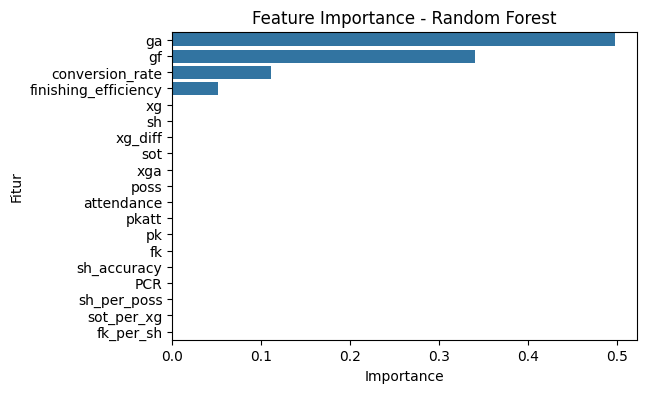

In [49]:
# Visualisasikan
plt.figure(figsize=(6,4))
sns.barplot(x='Importance', y='Fitur', data=importance_df)
plt.title('Feature Importance - Random Forest')
plt.show()

##### Split Data Train and Data Test

In [50]:
y = data_model['target_pred'].astype(int)  # make sure data type in int and value is 0, 1, 2
X = data_model[['ga', 'conversion_rate', 'PCR', 'finishing_efficiency', 'sh_per_poss']]
# X = data_model[[ 'conversion_rate', 'PCR', 'finishing_efficiency', 'gf', 'sh_accuracy', 'sot_per_xg']]

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42, test_size=0.2)

In [36]:
y_test.head()

2291    2
1817    0
2688    1
3137    0
1567    1
Name: target_pred, dtype: int64

##### ➡️ Try using Random Forest Method

In [52]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       314
           1       0.90      0.89      0.90       237
           2       0.94      0.94      0.94       313

    accuracy                           0.94       864
   macro avg       0.94      0.94      0.94       864
weighted avg       0.94      0.94      0.94       864

[[310   3   1]
 [  9 211  17]
 [  0  20 293]]


📌Summary: 

The model is already accurate in distinguishing the three classes, including the often problematic “series” class. But there is still room for improvisation and improvement to a more robust and generalization-tested model.

In [53]:
clf.predict_proba(X_test)

array([[0.  , 0.  , 1.  ],
       [1.  , 0.  , 0.  ],
       [0.  , 0.03, 0.97],
       ...,
       [0.  , 0.01, 0.99],
       [0.  , 0.02, 0.98],
       [0.91, 0.09, 0.  ]], shape=(864, 3))

✅ Use Stratified K-Fold Cross-Validation

For fairer validation and even distribution of labels in each fold:

In [54]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf = RandomForestClassifier(random_state=42)

scores = cross_val_score(clf, X, y, cv=skf, scoring='f1_macro')
print("F1-macro per fold:", scores)
print("Mean F1-macro:", scores.mean())

F1-macro per fold: [0.94197563 0.93723088 0.93588442 0.94689047 0.9475636 ]
Mean F1-macro: 0.9419090013680258


##### Tuning Random Forest

In [55]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [300],
    'max_depth': [None],
    'min_samples_split': [2],
    'class_weight': ['balanced']
}

grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=skf, scoring='f1_macro')
grid.fit(X, y)

print("Best parameters:", grid.best_params_)
print("Best F1-macro score:", grid.best_score_)

Best parameters: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
Best F1-macro score: 0.942057036100891


In [56]:
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='mlogloss'),
    "Logistic Regression": LogisticRegression(max_iter=500)
}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=skf, scoring='f1_macro')
    print(f"{name}: Mean F1-macro = {scores.mean():.4f}")

Random Forest: Mean F1-macro = 0.9419
XGBoost: Mean F1-macro = 0.9427
Logistic Regression: Mean F1-macro = 0.8876


In [57]:
from sklearn.ensemble import RandomForestClassifier

final_model = RandomForestClassifier(
    class_weight='balanced',
    max_depth=None,
    min_samples_split=2,
    n_estimators=300,
    random_state=42
)

final_model.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


##### Confusion Matrix

In [58]:
# Prediksi pada data test
y_pred = final_model.predict(X_test)

# Tampilkan classification report
print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

# Tampilkan confusion matrix
print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))


=== Classification Report ===
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       314
           1       0.91      0.89      0.90       237
           2       0.94      0.94      0.94       313

    accuracy                           0.94       864
   macro avg       0.94      0.94      0.94       864
weighted avg       0.94      0.94      0.94       864

=== Confusion Matrix ===
[[310   3   1]
 [  8 211  18]
 [  0  19 294]]


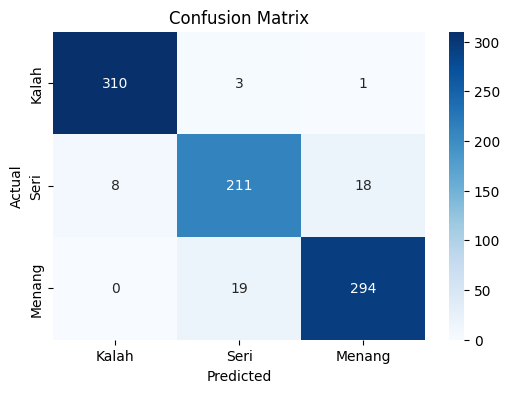

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

labels = ['Kalah', 'Seri', 'Menang']
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

##### Result & Conclusion

In [60]:
# 1. Buat DataFrame hasil prediksi vs aktual
df_result = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

In [61]:
# 2. (Opsional) Tambahkan probabilitas
y_proba = final_model.predict_proba(X_test)

df_result['Prob_Kalah'] = y_proba[:, 0]
df_result['Prob_Seri'] = y_proba[:, 1]
df_result['Prob_Menang'] = y_proba[:, 2]

In [62]:
# 3. (Opsional) Tambahkan fitur input yang digunakan
cols1 = [
    'date', 'venue', 'team', 'gf', 'ga','opponent',	'poss', 'result', 'attendance', 'season'	
]

# df_features = X_test.reset_index(drop=True)
# df_features1 = data_model[cols1].reset_index(drop=True)
# df_result = pd.concat([df_features1.reset_index(drop=True), df_result.reset_index(drop=True)], axis=1)

df_features = X_test.reset_index(drop=True)
df_result = pd.concat([df_features.reset_index(drop=True), df_result.reset_index(drop=True)], axis=1)

In [63]:
# 4. Tampilkan 10 baris pertama
df_result.sample(6)

,ga,conversion_rate,PCR,finishing_efficiency,sh_per_poss,Actual,Predicted,Prob_Kalah,Prob_Seri,Prob_Menang
79,1,0.181818,0.0,0.952381,0.244444,2,2,0.000000,0.020000,0.980000
534,0,0.200000,0.0,1.111111,0.211268,2,2,0.000000,0.000000,1.000000
708,3,0.120000,1.0,1.000000,0.543478,1,0,0.560000,0.326667,0.113333
369,2,0.200000,1.0,1.578947,0.333333,2,2,0.033333,0.290000,0.676667
77,0,0.090909,0.0,1.176471,0.338462,2,2,0.000000,0.003333,0.996667
432,0,0.105263,1.0,0.800000,0.395833,2,2,0.003333,0.006667,0.990000


In [64]:
df_result[df_result['Actual'] != df_result['Predicted']].sample(5)

,ga,conversion_rate,PCR,finishing_efficiency,sh_per_poss,Actual,Predicted,Prob_Kalah,Prob_Seri,Prob_Menang
858,2,0.250000,1.0,1.081081,0.275862,2,1,0.010000,0.833333,0.156667
367,2,0.625000,1.0,2.941176,0.100000,2,1,0.120000,0.773333,0.106667
270,2,0.200000,0.0,2.500000,0.322581,1,2,0.046667,0.470000,0.483333
105,2,0.153846,0.0,4.000000,0.203125,1,0,0.576667,0.333333,0.090000
838,3,0.333333,1.0,2.000000,0.200000,0,2,0.340000,0.270000,0.390000


#### Conclusion